Prove di predict_demand.py  
(full notebook on ARIMA.ipynb)

In [99]:
from predict_demand import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [100]:
df = build_hourly_dataframe(data_path='C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet', add_weather_info=True)

In [101]:
aggr_df = temporal_aggregation(df, 'D')

In [102]:
train, test = train_test_split(aggr_df, split_timestep = pd.Timestamp('2022-04-04 00:00:00'))

In [103]:
train, test, avg, sd = normalize(train, test)

In [104]:
ARIMA_model = fit_arima(train)

In [105]:
ARIMA_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  490
Model:               SARIMAX(3, 0, 1)   Log Likelihood                 -26.679
Date:                Thu, 29 Dec 2022   AIC                             99.359
Time:                        14:59:22   BIC                            195.830
Sample:                    11-30-2020   HQIC                           137.246
                         - 04-03-2022                                         
Covariance Type:                  opg                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
leisure             0.0834      0.016      5.080      0.000       0.051       0.116
public_services     0.0463      0.017      2.700      0.007       0.013       0.080
building            0.1060      0.015      7.117      0.000       0.077       0.135
education           0.0978      0.016      6.152      0.000       0.067       0.129
food                0.0896      0.023      3.916      0.000       0.045       0.134
transport           0.2516      0.025      9.912      0.000       0.202       0.301
finantial           0.0420      0.014      2.956      0.003       0.014       0.070
healthcare          0.0696      0.016      4.360      0.000       0.038       0.101
office              0.0718      0.017      4.347      0.000       0.039       0.104
shop                0.1014      0.025      4.064      0.000       0.053       0.150
tourism             0.0671      0.015      4.610      0.000       0.039       0.096
totalSnow_cm       -0.0179      0.011     -1.578      0.115      -0.040       0.004
windspeedKmph       0.0121      0.016      0.772      0.440      -0.019       0.043
tempC               0.0095      0.035      0.269      0.788      -0.060       0.079
visibility          0.0032      0.012      0.274      0.784      -0.020       0.026
precipMM           -0.0338      0.023     -1.452      0.147      -0.079       0.012
holiday            -0.0027      0.015     -0.178      0.858      -0.033       0.027
day                -0.0188      0.014     -1.342      0.180      -0.046       0.009
ar.L1               1.1380      0.074     15.360      0.000       0.993       1.283
ar.L2              -0.0458      0.064     -0.714      0.475      -0.171       0.080
ar.L3              -0.1094      0.057     -1.904      0.057      -0.222       0.003
ma.L1              -0.8191      0.059    -13.794      0.000      -0.936      -0.703
sigma2              0.0660      0.004     15.580      0.000       0.058       0.074
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                20.85
Prob(Q):                              0.79   Prob(JB):                         0.00
Heteroskedasticity (H):               2.24   Skew:                            -0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

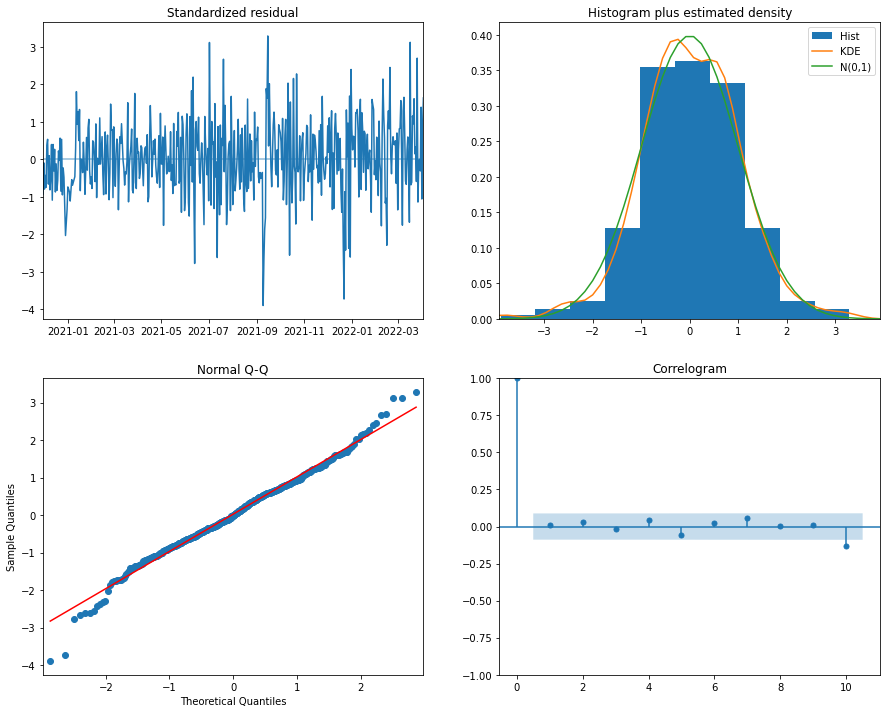

In [106]:
ARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [107]:
ARIMA_model.params()

leisure            0.083352
public_services    0.046257
building           0.105983
education          0.097787
food               0.089572
transport          0.251574
finantial          0.042011
healthcare         0.069603
office             0.071821
shop               0.101433
tourism            0.067095
totalSnow_cm      -0.017896
windspeedKmph      0.012130
tempC              0.009487
visibility         0.003219
precipMM          -0.033813
holiday           -0.002714
day               -0.018768
ar.L1              1.138007
ar.L2             -0.045777
ar.L3             -0.109416
ma.L1             -0.819127
sigma2             0.065997
dtype: float64

In [108]:
fitted, confint = predict_on_test(ARIMA_model, test)

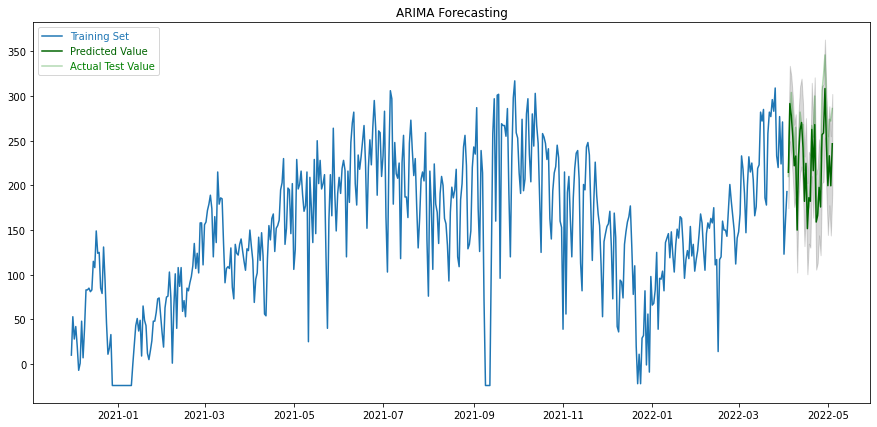

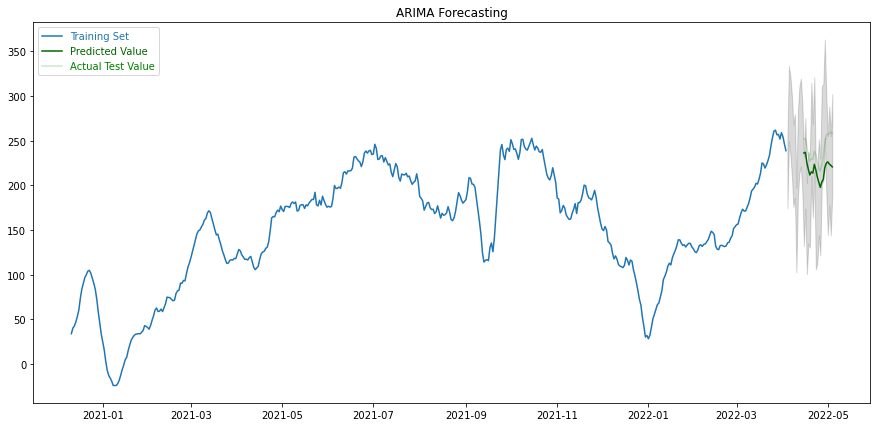

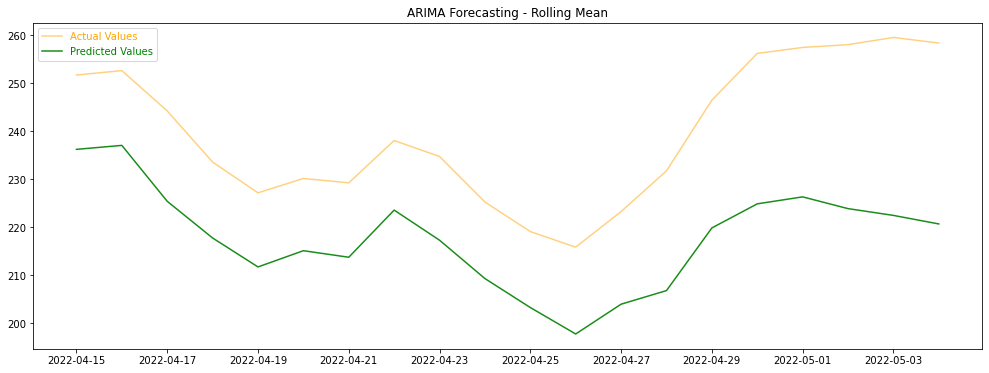

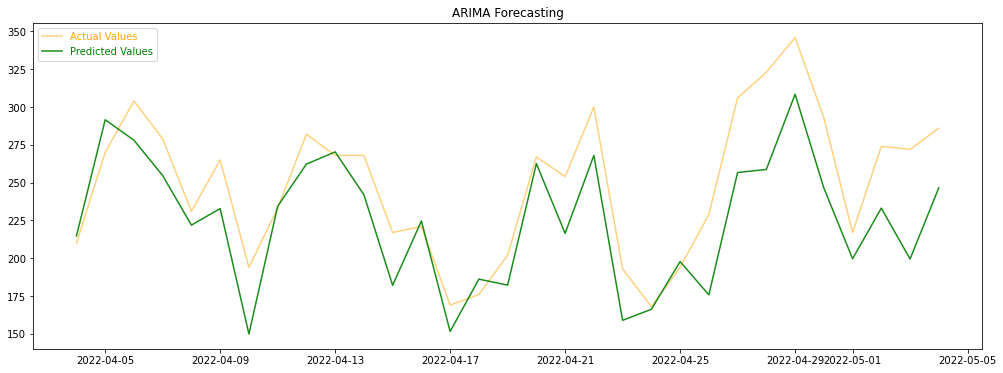

In [109]:
from matplotlib.pylab import rcParams
rcParams["figure.figsize"] = 17, 6
fitted, confint = predict_on_test(ARIMA_model, test)
plot_forecast(fitted, confint, train, test, 'D', avg, sd, model_name='ARIMA')

In [ ]:
# Mean Absolute Percentage Error
mape = np.mean(np.abs(fitted - test.trips_count)/np.abs(test.trips_count))
# Correlation
corr = np.corrcoef(fitted, test.trips_count)[0,1]  
# Min-Max Error
mins = np.amin(np.hstack([fitted[:,None], test.trips_count[:,None]]), axis=1)
maxs = np.amax(np.hstack([fitted[:,None], test.trips_count[:,None]]), axis=1)
minmax = 1 - np.mean(mins/maxs)

print('Mean Absolute Percentage Error:', mape, '\nCorrelation:', corr, '\nMin-Max Error:', minmax)